# Fluxo de tickets

Leitura da planilha `2024-10 Análise de Fluxo de Trabalho.xlsx` e visualização mensal do fluxo de tickets.

A planilha disponibilizada usa a aba `Fluxo de tickets` (não `fluxo de dados`). O código abaixo procura primeiro por `fluxo de dados` e, caso ela não exista, usa automaticamente `Fluxo de tickets`.

In [30]:
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go


## 1. Carregamento e preparação dos dados

In [31]:
arquivo = Path('2024-10 Análise de Fluxo de Trabalho.xlsx')
if not arquivo.exists():
    raise FileNotFoundError(f'Arquivo não encontrado: {arquivo.resolve()}')

xls = pd.ExcelFile(arquivo)
nomes_abas = {nome.casefold(): nome for nome in xls.sheet_names}
aba = nomes_abas.get('fluxo de dados', nomes_abas.get('fluxo de tickets'))
if aba is None:
    raise ValueError(f'Não encontrei a aba esperada. Abas disponíveis: {xls.sheet_names}')

# A linha 8 da planilha contém o primeiro registro mensal.
colunas = [
    'data',
    'fechados_saldo_ate_2020',
    'saldo_ate_2020',
    'tickets_criados_periodo',
    'fechados_no_periodo',
    'fechados_retroativamente',
    'fechados_sem_data_conclusao',
    'fechados_saldo_criados_a_partir_de_2021',
    'saldo_periodo',
    'fechados_total_periodo',
    'fechados_consolidado',
    'saldo_consolidado',
    'saldo_criados_a_partir_de_2021',
    'percentual_nao_concluidos_no_mes',
]

df = pd.read_excel(
    arquivo,
    sheet_name=aba,
    header=None,
    skiprows=7,
    usecols='B:O',
    names=colunas,
)

# O pandas pode ler datas Excel como datetime ou como números seriais.
# Tratamos os dois formatos antes de remover a linha de totais.
data_bruta = df['data']
data_convertida = pd.to_datetime(data_bruta, errors='coerce')
if data_convertida.notna().any():
    df['data'] = data_convertida
else:
    data_serial = pd.to_numeric(data_bruta, errors='coerce')
    df['data'] = pd.to_datetime(data_serial, unit='D', origin='1899-12-30', errors='coerce')
df = df[df['data'].notna()].copy()
for coluna in colunas[1:]:
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

df = df.sort_values('data').reset_index(drop=True)
df['mes'] = df['data'].dt.strftime('%b/%Y')
df.head()

,data,fechados_saldo_ate_2020,saldo_ate_2020,tickets_criados_periodo,fechados_no_periodo,fechados_retroativamente,fechados_sem_data_conclusao,fechados_saldo_criados_a_partir_de_2021,saldo_periodo,fechados_total_periodo,fechados_consolidado,saldo_consolidado,saldo_criados_a_partir_de_2021,percentual_nao_concluidos_no_mes,mes
0,2020-12-01,NaN,1215.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1215.0,NaN,0.000000,Dec/2020
1,2021-01-01,73.0,1142.0,194.0,94.0,8.0,44.0,0.0,48.0,146.0,219.0,1190.0,48.0,0.247423,Jan/2021
2,2021-02-01,100.0,1042.0,335.0,167.0,2.0,22.0,21.0,144.0,191.0,312.0,1213.0,171.0,0.429851,Feb/2021
3,2021-03-01,67.0,975.0,474.0,257.0,0.0,31.0,59.0,186.0,288.0,414.0,1273.0,298.0,0.392405,Mar/2021
4,2021-04-01,20.0,955.0,346.0,190.0,1.0,24.0,84.0,131.0,215.0,319.0,1300.0,345.0,0.378613,Apr/2021


In [32]:
print(f'Aba utilizada: {aba}')
if not pd.api.types.is_datetime64_any_dtype(df['data']):
    datas_numericas = pd.to_numeric(df['data'], errors='coerce')
    if datas_numericas.notna().any():
        df['data'] = pd.to_datetime(datas_numericas, unit='D', origin='1899-12-30', errors='coerce')
    else:
        df['data'] = pd.to_datetime(df['data'], errors='coerce')
inicio = df['data'].min()
fim = df['data'].max()
print('Período: {} a {}'.format(inicio.strftime('%m/%Y'), fim.strftime('%m/%Y')))
print(f'Quantidade de registros mensais: {len(df)}')

resumo = df[[
    'tickets_criados_periodo',
    'fechados_no_periodo',
    'fechados_retroativamente',
    'fechados_sem_data_conclusao',
    'fechados_saldo_criados_a_partir_de_2021',
    'saldo_consolidado',
]].sum().to_frame('total')
resumo

Aba utilizada: Fluxo de tickets
Período: 12/2020 a 09/2024
Quantidade de registros mensais: 46


,total
tickets_criados_periodo,24757.0
fechados_no_periodo,15743.0
fechados_retroativamente,520.0
fechados_sem_data_conclusao,230.0
fechados_saldo_criados_a_partir_de_2021,6876.0
saldo_consolidado,65897.0


As barras empilhadas mostram o saldo remanescente do mês e os tickets criados e encerrados no mês. A bolinha amarela no topo representa a soma dessas duas partes, isto é, os tickets criados no mês. A linha verde-azulada mostra o saldo remanescente anterior a 2020 e a linha vermelha mostra o saldo consolidado.


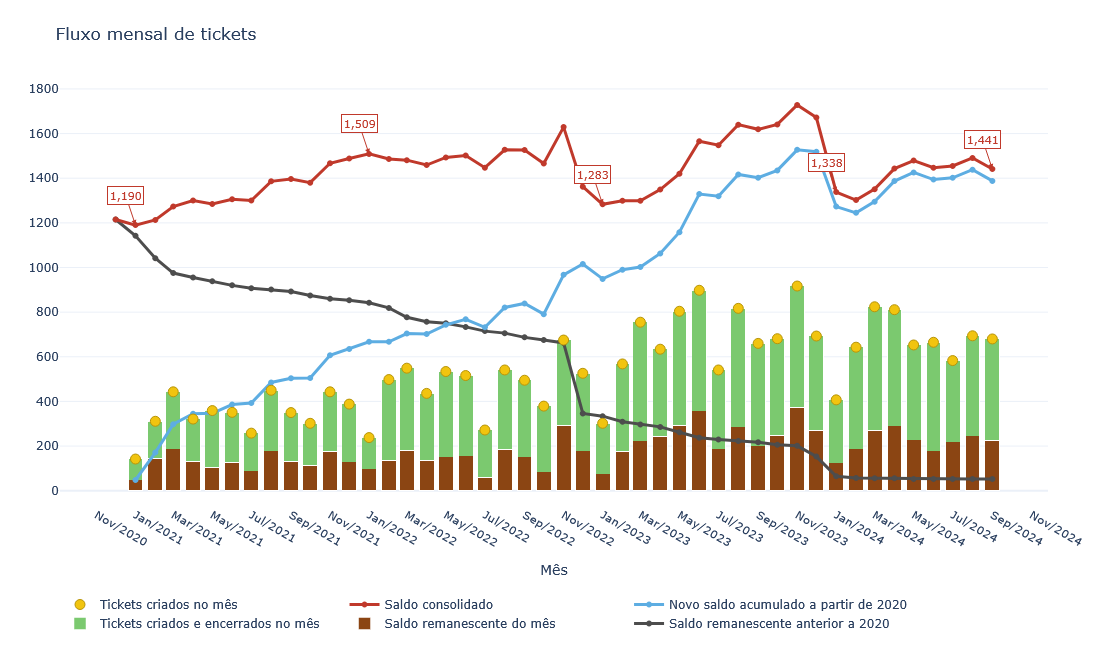

In [33]:

fig = go.Figure()
series_barras = {
    'saldo_periodo': ('Saldo remanescente do mês', '#8B4513'),
    'fechados_no_periodo': ('Tickets criados e encerrados no mês', '#7BC96F'),
}
fig.add_trace(
    go.Scatter(
        x=df['data'],
        y=df['saldo_ate_2020'],
        name='Saldo remanescente anterior a 2020',
        mode='lines+markers',
        line={'color': '#4D4D4D', 'width': 3},
    ),
)

for coluna, (rotulo, cor) in series_barras.items():
    fig.add_trace(
        go.Bar(x=df['data'], y=df[coluna], name=rotulo, marker_color=cor),
    )

fig.add_trace(
    go.Scatter(
        x=df['data'],
        y=df['saldo_criados_a_partir_de_2021'],
        name='Novo saldo acumulado a partir de 2020',
        mode='lines+markers',
        line={'color': '#5DADE2', 'width': 3},
    ),
)

fig.add_trace(
    go.Scatter(
        x=df['data'],
        y=df['saldo_consolidado'],
        name='Saldo consolidado',
        mode='lines+markers',
        line={'color': '#C0392B', 'width': 3},
    ),
)

fig.add_trace(
    go.Scatter(
        x=df['data'],
        y=df['fechados_no_periodo'] + df['saldo_periodo'],
        name='Tickets criados no mês',
        mode='markers',
        marker={'color': '#F1C40F', 'size': 10, 'line': {'color': '#B7950B', 'width': 1}},
    ),
)

fig.update_layout(
    title='Fluxo mensal de tickets',
    barmode='stack',
    hovermode='x unified',
    template='plotly_white',
    height=650,
    legend={'orientation': 'h', 'y': -0.2},
    margin={'l': 60, 'r': 60, 't': 80, 'b': 130},
)
fig.update_xaxes(title_text='Mês', tickformat='%b/%Y', dtick='M2')
pontos_destaque = df[
    (df['data'].dt.month == 1)
    | ((df['data'].dt.year == 2024) & (df['data'].dt.month == 9))
].dropna(subset=['saldo_consolidado'])

for _, ponto in pontos_destaque.iterrows():
    fig.add_annotation(
        x=ponto['data'],
        y=ponto['saldo_consolidado'],
        text=f"{ponto['saldo_consolidado']:,.0f}",
        showarrow=True,
        arrowhead=2,
        arrowcolor='#C0392B',
        bgcolor='white',
        bordercolor='#C0392B',
        font={'color': '#C0392B', 'size': 11},
    )

fig.show()

## 3. Indicador de conclusão no próprio mês

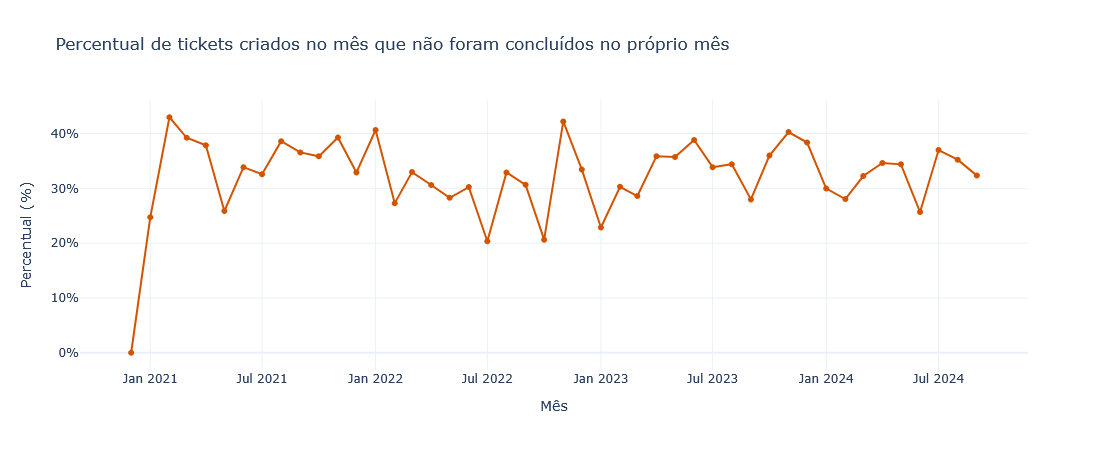

In [34]:
fig_percentual = go.Figure()
fig_percentual.add_trace(go.Scatter(
    x=df['data'],
    y=df['percentual_nao_concluidos_no_mes'] * 100,
    mode='lines+markers',
    name='Não concluídos no próprio mês',
    line={'color': '#D35400', 'width': 2},
))
fig_percentual.update_layout(
    title='Percentual de tickets criados no mês que não foram concluídos no próprio mês',
    yaxis_title='Percentual (%)',
    xaxis_title='Mês',
    yaxis={'ticksuffix': '%'},
    template='plotly_white',
    height=450,
)
fig_percentual.show()